In [1]:
import matplotlib.pyplot as plt
import h5py
import numpy as np
import astropy.units as u
import astropy.coordinates as coord

Below we load all the catalog elements related to galaxy positions. They all have metadata associated with them in the hdf5 file, although (at least with VSCode's `H5Web` viewer) unfortunately not all symbols are correctly rendered. For example, `lightconeAngularTheta` correspons to $\theta$ in a spherical coordinate system.

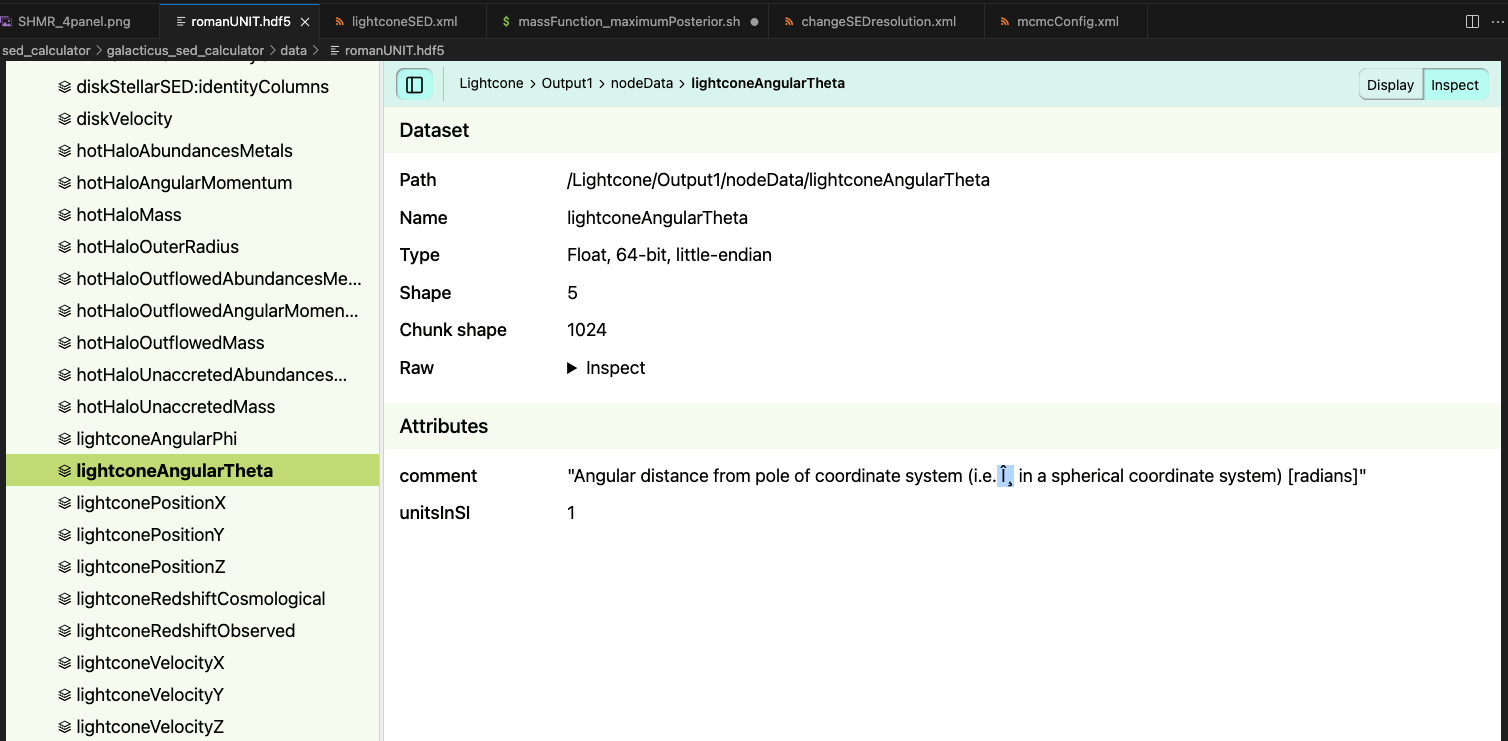

In [2]:
with h5py.File("data/romanUNIT.hdf5", 'r') as f:
    lightconeAngularPhi = f['Lightcone/Output1/nodeData/lightconeAngularPhi'][:]
    lightconeAngularTheta = f['Lightcone/Output1/nodeData/lightconeAngularTheta'][:]
    lightconePositionX = f['Lightcone/Output1/nodeData/lightconePositionX'][:]
    lightconePositionY = f['Lightcone/Output1/nodeData/lightconePositionY'][:]
    lightconePositionZ = f['Lightcone/Output1/nodeData/lightconePositionZ'][:]
    lightconeRedshiftCosmological = f['Lightcone/Output1/nodeData/lightconeRedshiftCosmological'][:]
    lightconeRedshiftObserved = f['Lightcone/Output1/nodeData/lightconeRedshiftObserved'][:]

In terms of placing Galacticus galaxies onto the sky (with RA and Dec, for example), the `lightconeAngularPhi` and `lightconeAngularTheta` are already angles, being the usual $\phi$ and $\theta$ for a [spherical coordinate system](https://en.wikipedia.org/wiki/Spherical_coordinate_system). Note that this lightcone is very small, a square with a side length of just $0.5^\circ$ (it also has $10\,000 \times$ lower number density than the full lightcone will have).

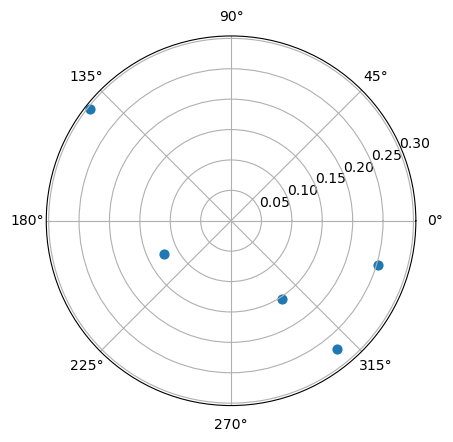

In [3]:
# Polar plot
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.scatter(lightconeAngularPhi, np.rad2deg(lightconeAngularTheta), s=40)  # azimuth first (in radians), then radius (here in degrees)
plt.show()

An easy way to have these correspond to positions on the sky would be

In [4]:
RA = np.rad2deg(lightconeAngularPhi) # RA in degrees
Dec = 90 - np.rad2deg(lightconeAngularTheta) # Dec in degrees (90 - theta to convert from polar to celestial coordinates)

Where the centre of the field will now point along the polar direction (Dec=$90^\circ$)

The X, Y and Z positions are in co-moving Mpc, with X "along the line-of-sight", while Y and Z are orthogonal to this. Because I don't often think in terms of RA and Dec, doing the roation in terms of these cartesian coordinates is more intuitive to me!

In [5]:
c = coord.SkyCoord(x=lightconePositionX, y=lightconePositionY, z=lightconePositionZ, unit='Mpc', representation_type='cartesian')
c.representation_type = 'spherical'
print(c)

<SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, Mpc)
    [(8.42604859e-02, -0.12941219, 4361.59005304),
     (3.59888891e+02, -0.05534602, 2402.43780366),
     (3.59768766e+02,  0.18381984, 4905.6937415 ),
     (2.42081548e-01, -0.07223136, 4858.24583652),
     (1.73799083e-01, -0.21078782,  888.66938939)]>


Let's plot these

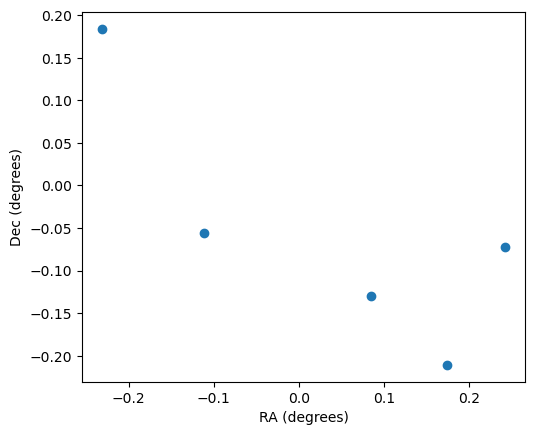

In [6]:
RA = c.ra.to_value('deg')
Dec = c.dec.to_value('deg')
RA[RA>180] -= 360
plt.scatter(RA, Dec)
plt.xlabel('RA (degrees)')
plt.ylabel('Dec (degrees)')
plt.gca().set_aspect('equal', adjustable='box')

Which is the same pattern of galaxies as in the polar plot above, but now on the equator.

I assume that there are relatively easy ways to rotate these so that the field is at an arbitrary RA and Dec, and with some particular roll angle. As someone who doesn't spend much time thinking about points on spheres I don't know what the best way to do this is, so suggestions most welcome!

Astropy has various rotation-like things, it just isn't super-clear to me how any of them work!
- https://docs.astropy.org/en/stable/api/astropy.coordinates.SkyOffsetFrame.html#astropy.coordinates.SkyOffsetFrame.rotation
- https://docs.astropy.org/en/stable/api/astropy.modeling.rotations.RotateNative2Celestial.html#astropy.modeling.rotations.RotateNative2Celestial.evaluate
- https://docs.astropy.org/en/stable/api/astropy.modeling.rotations.RotationSequence3D.html#astropy.modeling.rotations.RotationSequence3D.angles